# New-panel climate-GEA — SNP vs non-SNP: **binomial regression** + **Kendall-tau** (raw, no WZA)

The other two phase-1 GEA tests (companions to the LFMM notebook), run on the new arch3 panel and split **SNP** (1.99M records) vs **non-SNP = indel+SV pooled** (693k). Both are **raw per-record** scans across the 355 gen9 `site_gen_plot` pools vs **bio1**, MAF≥0.05, flower-weighted Δp. **No WZA** — raw frequencies only.

- **Binomial** (`run_binomial.py`): per-record GLM `[alt,ref] ~ const + z(bio1)`, counts = AF×flowers×2; slope + Wald p.
- **Kendall** (`run_kendall.py`): per-record tau-b between per-pool AF and bio1.

Pools within a site share a climate value (pseudoreplication) — same as phase-1; these raw scans do **not** correct structure (that is LFMM/WZA's job). So the comparison here is SNP-vs-nonSNP *relative* signal under identical, uncorrected tests.

In [1]:
import sys, os
PROJ='/global/scratch/users/tbellg/kmate'
sys.path.insert(0, f'{PROJ}/analysis/grenenet_gea')            # lib.py
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib as mpl
import scipy.stats as st, lib
mpl.rcParams.update({'figure.dpi':110,'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
GNP=f'{PROJ}/analysis/grenenet_gea/gea_newpanel/results'
OUT=f'{GNP}/binom_kendall'; os.makedirs(OUT, exist_ok=True)
CHR=[f'Chr{i}' for i in range(1,6)]
ACC={'snp':'#c1443c','nonsnp':'#2e7d5b'}; NAME={'snp':'SNP','nonsnp':'non-SNP (indel+SV)'}
TESTS={'binomial':'binomial','kendall':'kendall'}

## Load per-record raw scans (binomial + kendall, both classes), build genome coords

In [2]:
dat={}   # dat[(test,cls)] -> DataFrame
for test in ['binomial','kendall']:
    for cls in ['snp','nonsnp']:
        d=pd.read_csv(f'{GNP}/{test}/{test}_{cls}_gen9_bio1.csv')
        d=d[np.isfinite(d.pval)].copy(); d['nlp']=-np.log10(d.pval.clip(1e-300))
        dat[(test,cls)]=d
# genome offsets from max pos per chrom across everything
chrlen={}
for c in CHR:
    chrlen[c]=int(max(D.loc[D.chrom==c,'pos'].max() for D in dat.values()))
off={}; run=0
for c in CHR: off[c]=run; run+=chrlen[c]+int(2e6)
ticks=[off[c]+chrlen[c]/2 for c in CHR]
for D in dat.values(): D['gx']=D.pos.astype(float)+D.chrom.map(off)
for test in ['binomial','kendall']:
    for cls in ['snp','nonsnp']:
        d=dat[(test,cls)]
        print(f'{test:9s} {cls:7s}: {len(d):>9,} records tested | min p={d.pval.min():.1e} '
              f'| p<1e-5: {(d.pval<1e-5).sum():>4d} | p<0.05: {(d.pval<0.05).sum():>8,}')

binomial  snp    : 2,016,071 records tested | min p=1.0e-300 | p<1e-5: 1417079 | p<0.05: 1,746,426
binomial  nonsnp :   703,789 records tested | min p=1.0e-300 | p<1e-5: 493349 | p<0.05:  609,031
kendall   snp    : 2,016,071 records tested | min p=2.2e-20 | p<1e-5: 203001 | p<0.05: 1,065,958
kendall   nonsnp :   703,789 records tested | min p=9.9e-21 | p<1e-5: 71452 | p<0.05:  370,458


## Raw per-record Manhattans
Each panel = one class; top row SNP, bottom non-SNP. Dashed = per-panel Bonferroni (0.05/n_tested); dotted gold = BH FDR q<0.05 line if any pass. Points thinned by uniform subsample (real hits nlp>2 always kept). These are raw, structure-uncorrected scans — read them as relative SNP-vs-nonSNP signal, not calibrated significance.

In [3]:
cols={'Chr1':'#3b5b92','Chr2':'#8bb0d0','Chr3':'#3b5b92','Chr4':'#8bb0d0','Chr5':'#3b5b92'}
def _bh(p):
    p=np.asarray(p,float); n=len(p); o=np.argsort(p); q=np.empty(n)
    q[o]=(p[o]*n)/(np.arange(n)+1); q[o]=np.minimum.accumulate(q[o][::-1])[::-1]; return np.clip(q,0,1)
def manhattan(test, fname, pcol='pval', tag='RAW '):
    fig,axes=plt.subplots(2,1,figsize=(13,6.5),sharex=True)
    for ax,cls in zip(axes,['snp','nonsnp']):
        d=dat[(test,cls)].copy()
        d['_nlp']=-np.log10(d[pcol].clip(1e-300))
        pv=d[pcol].to_numpy(float); pv=pv[np.isfinite(pv)]; nt=len(pv)
        bonf=-np.log10(0.05/nt); pas=pv[_bh(pv)<0.05]
        fdr=float(-np.log10(pas.max())) if pas.size else None
        base=d.sample(frac=min(1.0,250000/len(d)),random_state=0) if len(d)>250000 else d
        t=pd.concat([base,d[d._nlp>2]]).drop_duplicates(subset=['gx','_nlp'])
        ax.scatter(t.gx,t._nlp,s=3,c=t.chrom.map(cols),rasterized=True,linewidths=0)
        ax.axhline(bonf,ls='--',lw=1.0,color='#444',label=f'Bonferroni ({bonf:.1f})')
        if fdr is not None: ax.axhline(fdr,ls=':',lw=1.3,color='#b8860b',label=f'FDR q<.05 ({fdr:.1f})')
        else: ax.plot([],[],' ',label='FDR q<.05: none pass')
        top=d.nlargest(1,'_nlp').iloc[0]
        ax.scatter([top.gx],[top._nlp],s=42,facecolors='none',edgecolors=ACC[cls],linewidths=1.6,zorder=5)
        ax.annotate(f'{top.chrom}:{int(top.pos):,} {top.block}',(top.gx,top._nlp),
                    xytext=(6,-1),textcoords='offset points',fontsize=8,color=ACC[cls])
        ax.set_ylabel('-log10 p'+(' (GIF-corr)' if pcol!='pval' else ''))
        ax.text(0.995,0.90,NAME[cls],transform=ax.transAxes,ha='right',fontweight='bold',color=ACC[cls])
        ax.set_ylim(-0.4, max(float(d._nlp.max()),bonf)*1.10)
        ax.legend(loc='upper left',fontsize=7.5,frameon=False,handlelength=1.6)
    axes[1].set_xticks(ticks); axes[1].set_xticklabels(CHR); axes[1].set_xlabel('genome position')
    fig.suptitle(f'{tag}{test} climate-GEA (bio1, gen9) — SNP vs non-SNP',y=0.98); fig.tight_layout()
    fig.savefig(f'{OUT}/{fname}',dpi=150,bbox_inches='tight'); plt.show()
    print('wrote',fname)

### Binomial-regression Manhattan

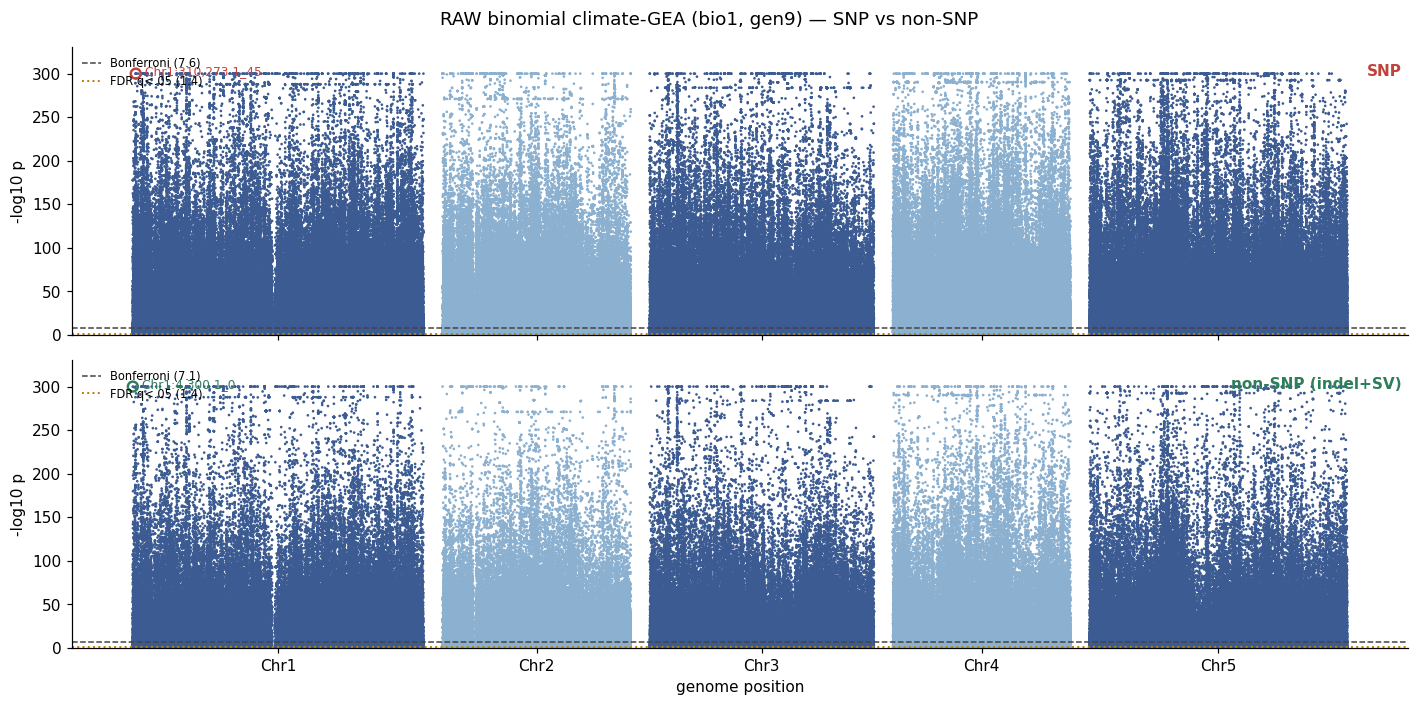

wrote manhattan_binomial_snp_vs_nonsnp.png


In [4]:
manhattan('binomial','manhattan_binomial_snp_vs_nonsnp.png')

### Kendall-tau Manhattan

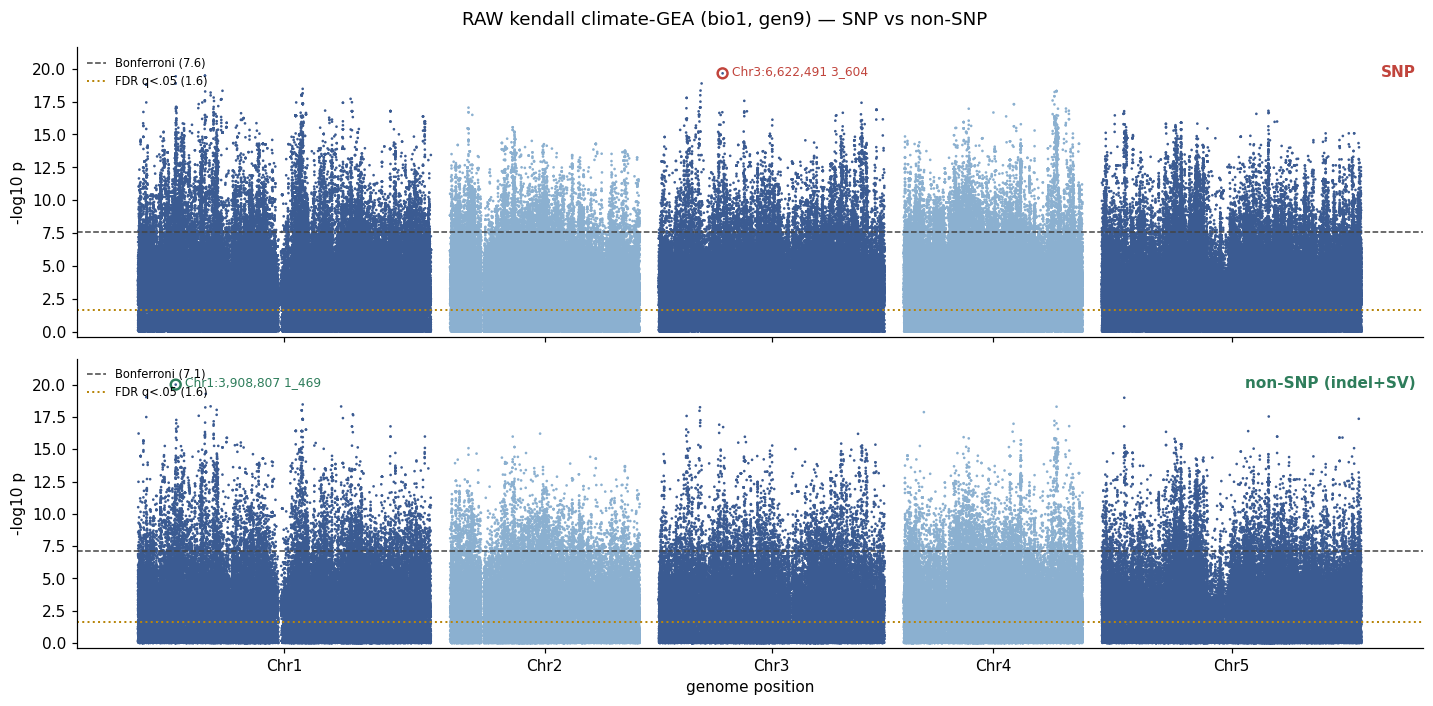

wrote manhattan_kendall_snp_vs_nonsnp.png


In [5]:
manhattan('kendall','manhattan_kendall_snp_vs_nonsnp.png')

## Raw top hits per test/class — gene-annotated
Top records straight from each test, with the overlapping TAIR10 gene (±2 kb).

In [6]:
genes=lib.load_genes()
def annotate(t):
    a=lib.annotate_svs(t.copy(), flank=2000, genes=genes)
    t=t.copy(); t['gene_name']=a.gene_name.values; t['genes']=a.genes_all.values; return t
def top(test,cls,n=20):
    d=dat[(test,cls)]
    stat='slope' if test=='binomial' else 'tau'
    t=d.nsmallest(n,'pval')[['chrom','pos','ref_len','alt_len','MAF','block',stat,'pval']]
    return annotate(t).reset_index(drop=True)
for test in ['binomial','kendall']:
    for cls in ['snp','nonsnp']:
        top(test,cls).to_csv(f'{OUT}/top_{test}_{cls}_annotated.csv',index=False)
pd.set_option('display.width',220,'display.max_colwidth',38)
print('saved top-record tables to',OUT)

saved top-record tables to /global/scratch/users/tbellg/kmate/analysis/grenenet_gea/gea_newpanel/results/binom_kendall


### Binomial — top SNP records

In [7]:
top('binomial','snp')

,chrom,pos,ref_len,alt_len,MAF,block,slope,pval,gene_name,genes
0,Chr1,310273,1,1,0.130912,1_45,0.722354,1.000000e-300,AT1G01880,AT1G01880;AT1G01900
1,Chr1,317357,1,1,0.117222,1_45,0.771151,1.000000e-300,AT1G01910,AT1G01910;AT1G01920
2,Chr1,318255,1,1,0.115257,1_45,0.730445,1.000000e-300,AT1G01920,AT1G01920;AT1G01930
3,Chr1,321016,1,1,0.117367,1_45,0.729112,1.000000e-300,AT1G01920,AT1G01920;AT1G01930
4,Chr1,345573,1,1,0.141267,1_45,0.707295,1.000000e-300,AT1G01990,AT1G01990;AT1G02000
5,Chr1,554430,1,1,0.123149,1_104,0.726589,1.000000e-300,AT1G02590,AT1G02590;AT1G02610
6,Chr1,911098,1,1,0.370074,1_151,0.495144,1.000000e-300,AT1G03630,AT1G03630;AT1G03650;AT1G03660
7,Chr1,911108,1,1,0.370074,1_151,0.495144,1.000000e-300,AT1G03630,AT1G03630;AT1G03650;AT1G03660
8,Chr1,911139,1,1,0.370074,1_151,0.495144,1.000000e-300,AT1G03630,AT1G03630;AT1G03650;AT1G03660
9,Chr1,911144,1,1,0.370074,1_151,0.495144,1.000000e-300,AT1G03630,AT1G03630;AT1G03650;AT1G03660


### Binomial — top non-SNP records

In [8]:
top('binomial','nonsnp')

,chrom,pos,ref_len,alt_len,MAF,block,slope,pval,gene_name,genes
0,Chr1,4300,29,1,0.074042,1_0,0.990484,1.000000e-300,AT1G01010,AT1G01010;AT1G01020
1,Chr1,282880,2,1,0.190670,1_45,0.590718,1.000000e-300,AT1G01770,AT1G01770;AT1G01780;AT1G01790
2,Chr1,911179,1,2,0.370074,1_151,0.495144,1.000000e-300,AT1G03630,AT1G03630;AT1G03650;AT1G03660
3,Chr1,911306,1,3,0.375414,1_151,0.502197,1.000000e-300,AT1G03630,AT1G03630;AT1G03650;AT1G03660
4,Chr1,911465,1,4,0.381345,1_151,0.484410,1.000000e-300,AT1G03650,AT1G03650;AT1G03660
5,Chr1,913681,2,2,0.114689,1_151,0.792829,1.000000e-300,AT1G03660,AT1G03660;AT1G03670
6,Chr1,971198,4,4,0.109881,1_162,0.870449,1.000000e-300,AT1G03840,AT1G03840
7,Chr1,1086898,2,1,0.220591,1_168,0.552573,1.000000e-300,AT1G04160,AT1G04160
8,Chr1,1086927,2,11,0.220591,1_168,0.552573,1.000000e-300,AT1G04160,AT1G04160
9,Chr1,1086943,16,1,0.220591,1_168,0.552573,1.000000e-300,AT1G04160,AT1G04160


### Kendall — top SNP records

In [9]:
top('kendall','snp')

,chrom,pos,ref_len,alt_len,MAF,block,tau,pval,gene_name,genes
0,Chr3,6622491,1,1,0.052247,3_604,-0.335256,2.249739e-20,AT3G19160,AT3G19160
1,Chr1,6948335,1,1,0.084539,1_742,-0.333645,3.364269e-20,AT1G20030,AT1G20030;AT1G20050
2,Chr1,6948337,1,1,0.084539,1_742,-0.333645,3.364269e-20,AT1G20030,AT1G20030;AT1G20050
3,Chr1,3909064,1,1,0.092134,1_469,-0.333163,3.802452e-20,AT1G11610,AT1G11610;AT1G11620
4,Chr1,3897953,1,1,0.111319,1_469,-0.328331,1.297331e-19,AT1G11593,AT1G11593
5,Chr1,3898065,1,1,0.111319,1_469,-0.328331,1.297331e-19,AT1G11593,AT1G11593
6,Chr3,4439861,1,1,0.052041,3_502,-0.328297,1.324342e-19,AT3G13594,AT3G13594
7,Chr1,847069,1,1,0.054451,1_151,-0.327467,1.630012e-19,AT1G03410,AT1G03410;AT1G03430
8,Chr1,847077,1,1,0.054451,1_151,-0.327467,1.630012e-19,AT1G03410,AT1G03410;AT1G03430
9,Chr1,847404,1,1,0.054451,1_151,-0.327467,1.630012e-19,AT1G03410,AT1G03410;AT1G03430


### Kendall — top non-SNP records

In [10]:
top('kendall','nonsnp')

,chrom,pos,ref_len,alt_len,MAF,block,tau,pval,gene_name,genes
0,Chr1,3908807,1,4,0.087799,1_469,-0.338379,9.883188e-21,AT1G11608,AT1G11608;AT1G11610
1,Chr1,7032132,2,1,0.112631,1_763,-0.331947,5.171110e-20,AT1G20300,AT1G20300;AT1G20310;AT1G20320
2,Chr1,848324,2,2,0.051345,1_151,-0.329735,9.216737e-20,AT1G03410,AT1G03410;AT1G03430
3,Chr5,2322098,9,1,0.076389,5_298,-0.329260,1.027456e-19,AT5G07350,AT5G07350
4,Chr1,17105682,1,2,0.165960,1_2293,0.324499,3.399888e-19,AT1G45190,AT1G45190
5,Chr1,7536514,47,1,0.058114,1_895,-0.323191,4.759084e-19,AT1G21520,AT1G21520
6,Chr1,21102926,1,12,0.235355,1_2880,-0.323077,4.857948e-19,AT1G56380,AT1G56380
7,Chr4,15869443,2,2,0.090323,4_2802,-0.322907,5.060991e-19,AT4G32880,AT4G32880
8,Chr3,4274914,2,1,0.052535,3_499,-0.322578,5.581546e-19,AT3G13235,AT3G13235;AT3G13240
9,Chr1,6984081,2,1,0.139054,1_747,-0.322381,5.768312e-19,AT1G20132,AT1G20132;AT1G20135


## Concordance — do the tests and classes agree?
(a) **Within class, across tests**: Spearman of -log10 p between binomial and kendall (records shared by chrom:pos). (b) **Within test, across classes**: SNP-vs-nonSNP peak concordance at the phase-1 LD-block level (block peak = min per-record p), matching the LFMM notebook's block-Spearman. (c) Class-specific top-p records that the other class misses.

In [11]:
# unique record key: chrom,pos,ref_len,alt_len (pos alone collides on multi-allelic sites)
def key(d): return (d.chrom.astype(str)+':'+d.pos.astype(str)+':'
                    +d.ref_len.astype(str)+':'+d.alt_len.astype(str))
# (a) within-class across-test Spearman on -log10 p
print('=== (a) within-class, binomial vs kendall -log10p Spearman ===')
for cls in ['snp','nonsnp']:
    b=dat[('binomial',cls)].assign(k=lambda x:key(x)).drop_duplicates('k')[['k','nlp']].rename(columns={'nlp':'nlp_b'})
    kd=dat[('kendall',cls)].assign(k=lambda x:key(x)).drop_duplicates('k')[['k','nlp']].rename(columns={'nlp':'nlp_k'})
    m=b.merge(kd,on='k')
    rho=st.spearmanr(m.nlp_b,m.nlp_k).correlation
    print(f'  {cls:7s}: n_shared={len(m):>9,}  Spearman rho={rho:.3f}')
# (b) within-test across-class LD-block peak concordance
print('\n=== (b) within-test, SNP vs non-SNP LD-block peak (min-p) Spearman ===')
def block_peak(test,cls):
    d=dat[(test,cls)]; d=d[d.block!='']
    return d.groupby('block').pval.min().rename('p')
for test in ['binomial','kendall']:
    ps=block_peak(test,'snp'); pn=block_peak(test,'nonsnp')
    j=pd.concat([ps,pn],axis=1,join='inner',keys=['snp','non'])
    rho=st.spearmanr(-np.log10(j['snp'].clip(1e-300)),-np.log10(j['non'].clip(1e-300))).correlation
    print(f'  {test:9s}: shared LD-blocks={len(j):>6,}  peak Spearman rho={rho:.3f}')

=== (a) within-class, binomial vs kendall -log10p Spearman ===


  snp    : n_shared=1,995,278  Spearman rho=0.697


  nonsnp : n_shared=  682,577  Spearman rho=0.695

=== (b) within-test, SNP vs non-SNP LD-block peak (min-p) Spearman ===


  binomial : shared LD-blocks=13,988  peak Spearman rho=0.704


  kendall  : shared LD-blocks=13,988  peak Spearman rho=0.653


### Class-specific top records (raw)
Records in one class's top-p tail whose *nearest* record in the other class (same LD block, min p) is unremarkable — i.e. signal one class carries and the other misses.

In [12]:
def class_specific(test, lead='nonsnp', other='snp', topn=40, other_thresh=1e-3):
    d=dat[(test,lead)]
    stat='slope' if test=='binomial' else 'tau'
    cand=d.nsmallest(topn,'pval').copy()
    other_blockmin=dat[(test,other)][dat[(test,other)].block!=''].groupby('block').pval.min()
    cand['p_other_block']=cand.block.map(other_blockmin)
    spec=cand[(cand.block!='')&((cand.p_other_block.isna())|(cand.p_other_block>other_thresh))]
    spec=spec[['chrom','pos','ref_len','alt_len','MAF','block',stat,'pval','p_other_block']]
    return annotate(spec).reset_index(drop=True)
for test in ['binomial','kendall']:
    cs=class_specific(test)
    cs.to_csv(f'{OUT}/{test}_nonsnp_specific.csv',index=False)
    print(f'{test}: {len(cs)} non-SNP-specific top records (block p_snp>1e-3 or absent)')

binomial: 0 non-SNP-specific top records (block p_snp>1e-3 or absent)


kendall: 0 non-SNP-specific top records (block p_snp>1e-3 or absent)


#### Binomial — non-SNP-specific top records

In [13]:
class_specific('binomial')

,chrom,pos,ref_len,alt_len,MAF,block,slope,pval,p_other_block,gene_name,genes


#### Kendall — non-SNP-specific top records

In [14]:
class_specific('kendall')

,chrom,pos,ref_len,alt_len,MAF,block,tau,pval,p_other_block,gene_name,genes


## Controlling the inflation — genomic control (GIF), the LFMM recalibration
The raw binomial/Kendall p above are wildly inflated: the binomial GLM treats AF×flowers×2 (up to ~1350 genomes/pool) as that many independent draws (over-precision), and both tests soak up genome-wide structure and the pseudoreplication of 355 pools sharing only 31 climate values. **LFMM controls the analogous inflation with genomic control (`calibrate='gif'`)**: rescale the genome-wide χ² so the null is flat — λ = median(χ²_obs)/median(χ²_null,1df), then divide every statistic by λ and re-derive p. That recalibration is method-agnostic, so we apply the identical move here: recover a χ²₁ from each two-sided p (`chi2.isf(p,1)`), deflate by λ, back to `pval_gc`. **Caveat:** unlike LFMM (where the GIF only mops up residual inflation *after* K latent factors), here one global λ is absorbing structure + over-precision + pseudoreplication at once — it flattens the bulk but under-corrects a heavy tail, and it does NOT remove pseudoreplication at its source (that needs the 31-site honest unit, as in the LFMM notebook).

In [15]:
from scipy.stats import chi2
NULLMED=chi2.ppf(0.5,1)   # 0.4549 = median of a 1-df chi-square (the GIF null)
def gif(d):
    p=d.pval.to_numpy(float).clip(1e-300,1.0)
    x2=chi2.isf(p,1)                    # observed 1-df chi-square from the two-sided p
    lam=np.median(x2)/NULLMED           # genomic inflation factor (LFMM's GIF)
    return lam, chi2.sf(x2/lam,1)       # deflate by lambda -> recalibrated p
print('=== genomic-control (GIF) recalibration — the LFMM calibrate="gif" move ===')
print(f'{"scan":16s} {"GIF":>6s} | {"raw p<1e-5":>10s} {"GC p<1e-5":>10s} | '
      f'{"raw FDR<.05":>11s} {"GC FDR<.05":>11s}')
for test in ['binomial','kendall']:
    for cls in ['snp','nonsnp']:
        d=dat[(test,cls)]; lam,p_gc=gif(d)
        d['pval_gc']=p_gc
        r5=int((d.pval<1e-5).sum()); g5=int((p_gc<1e-5).sum())
        rf=int((_bh(d.pval.to_numpy(float))<0.05).sum()); gf=int((_bh(p_gc)<0.05).sum())
        print(f'{test+"/"+cls:16s} {lam:6.1f} | {r5:>10,} {g5:>10,} | {rf:>11,} {gf:>11,}')

=== genomic-control (GIF) recalibration — the LFMM calibrate="gif" move ===
scan                GIF | raw p<1e-5  GC p<1e-5 | raw FDR<.05  GC FDR<.05


binomial/snp      134.2 |  1,417,079          0 |   1,737,742           0


binomial/nonsnp   132.8 |    493,349          0 |     606,065           0


kendall/snp         9.6 |    203,001          0 |     922,841           0


kendall/nonsnp      9.5 |     71,452          0 |     320,174           0


### QQ plots — raw vs GIF-corrected
Grey = raw (line lifts far off the diagonal = inflation); coloured = after GIF deflation (bulk collapses onto the diagonal; residual tail excursions = candidate real signal). λ annotated per panel.

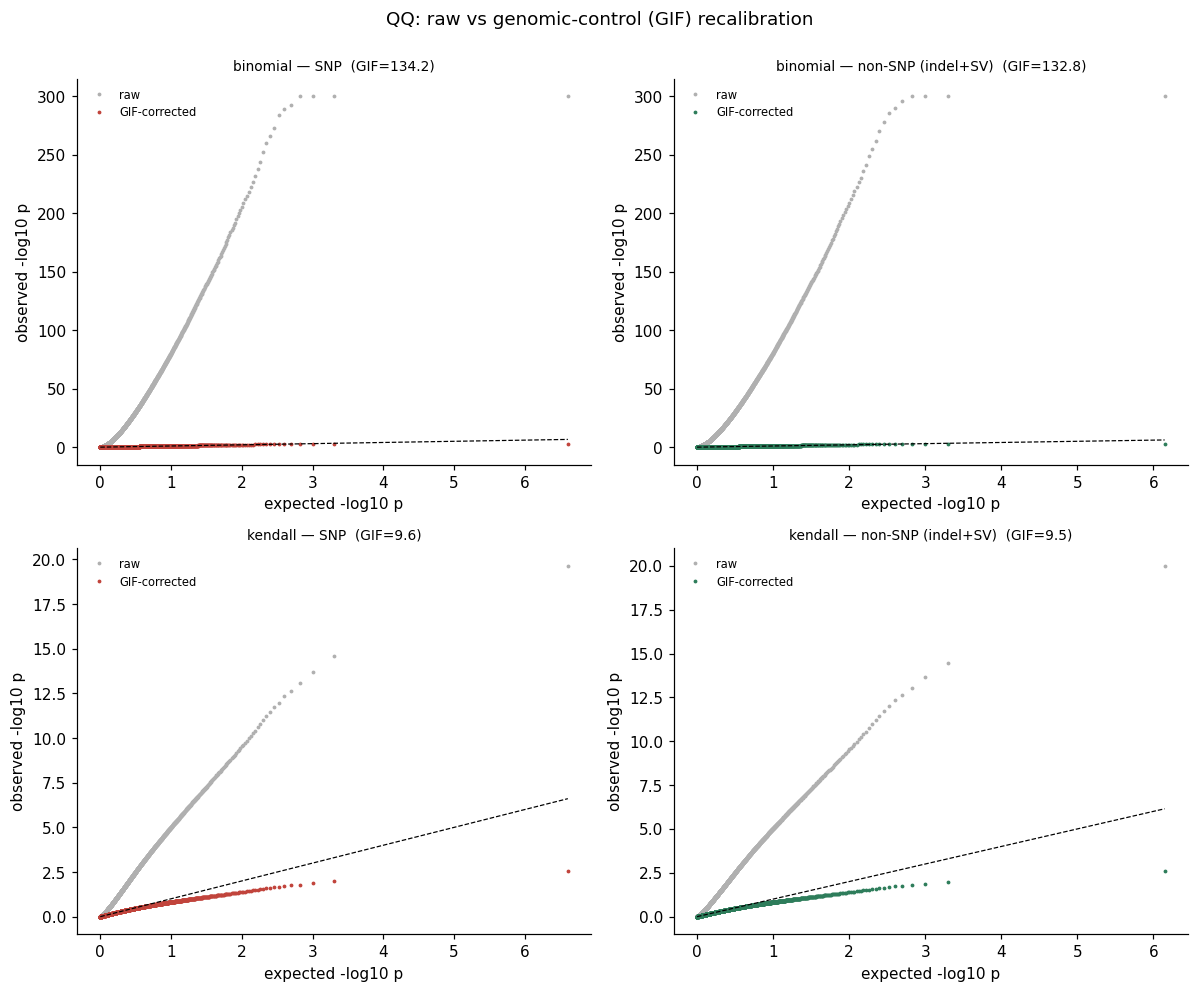

wrote qq_gif_binom_kendall.png


In [16]:
fig,axes=plt.subplots(2,2,figsize=(11,9))
combos=[(t,c) for t in ['binomial','kendall'] for c in ['snp','nonsnp']]
for ax,(test,cls) in zip(axes.ravel(),combos):
    d=dat[(test,cls)]; lam,_=gif(d)
    for col,color,label in [('pval','#b0b0b0','raw'),('pval_gc',ACC[cls],'GIF-corrected')]:
        p=np.sort(d[col].to_numpy(float)); n=len(p)
        exp=-np.log10((np.arange(1,n+1)-0.5)/n)
        obs=-np.log10(np.clip(p,1e-300,1))
        idx=np.unique(np.r_[np.linspace(0,n-1,2000).astype(int),np.arange(max(0,n-500),n)])
        ax.plot(exp[idx],obs[idx],'.',ms=3,color=color,label=label)
    mx=float(max(exp.max(),obs.max()))
    ax.plot([0,mx],[0,mx],'k--',lw=0.8)
    ax.set_title(f'{test} — {NAME[cls]}  (GIF={lam:.1f})',fontsize=9)
    ax.set_xlabel('expected -log10 p'); ax.set_ylabel('observed -log10 p')
    ax.legend(fontsize=7.5,frameon=False)
fig.suptitle('QQ: raw vs genomic-control (GIF) recalibration',y=0.997); fig.tight_layout()
fig.savefig(f'{OUT}/qq_gif_binom_kendall.png',dpi=140,bbox_inches='tight'); plt.show()
print('wrote qq_gif_binom_kendall.png')

### GIF-corrected Manhattans
Same scans after genomic control; the flat baseline is now honest, hits stand above it.

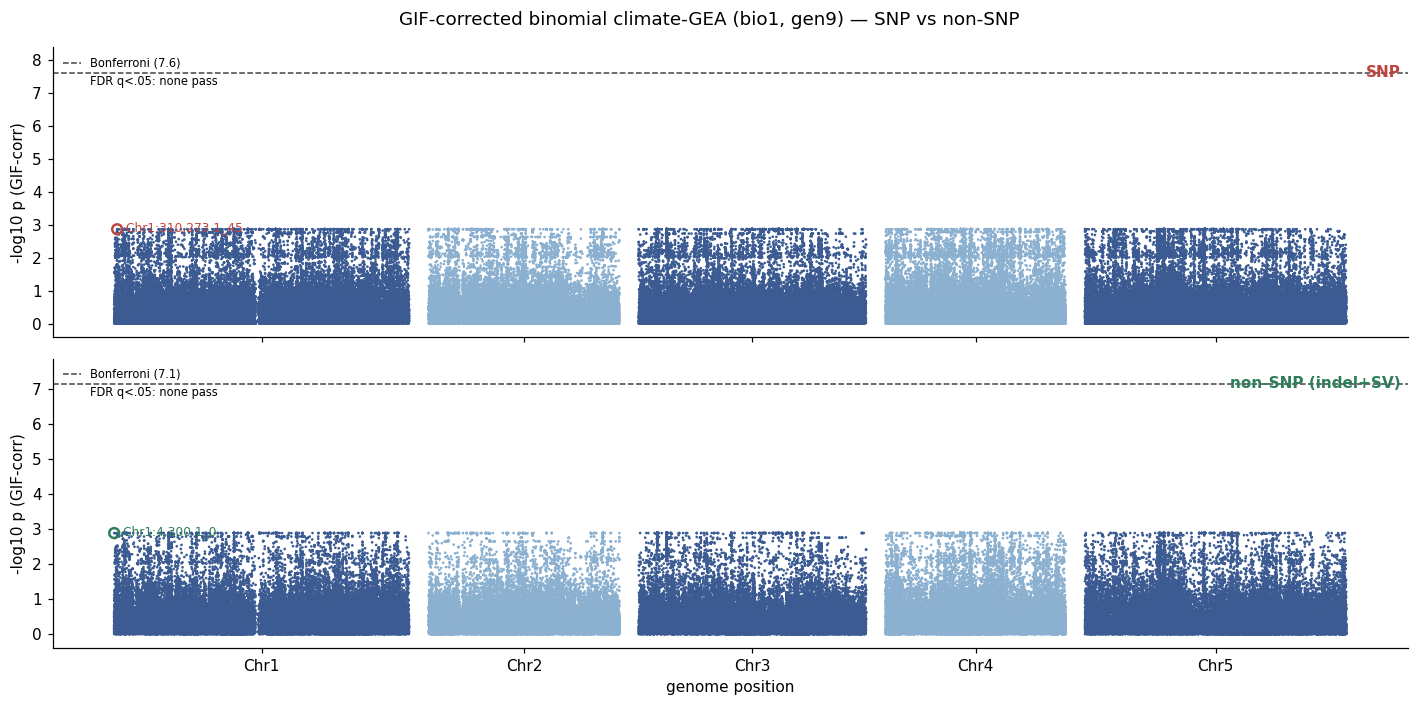

wrote manhattan_binomial_gc_snp_vs_nonsnp.png


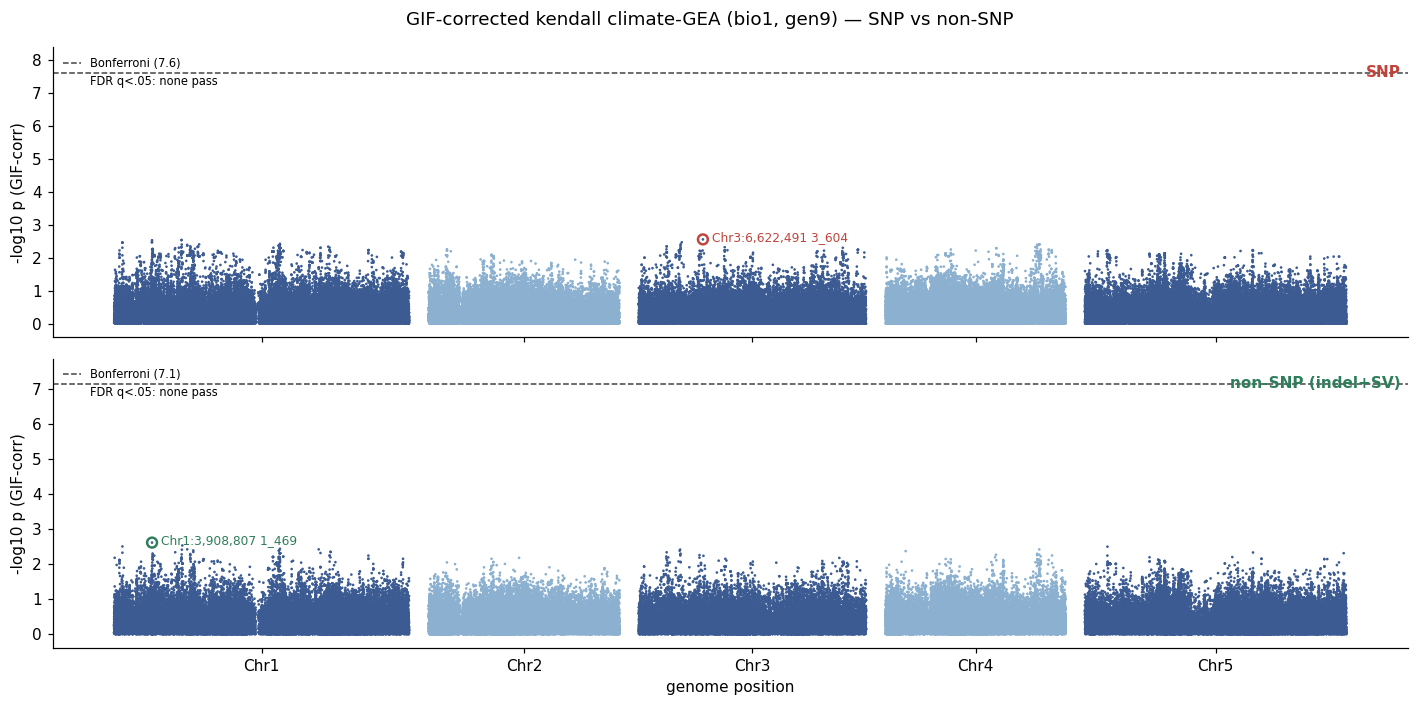

wrote manhattan_kendall_gc_snp_vs_nonsnp.png


In [17]:
manhattan('binomial','manhattan_binomial_gc_snp_vs_nonsnp.png',pcol='pval_gc',tag='GIF-corrected ')
manhattan('kendall','manhattan_kendall_gc_snp_vs_nonsnp.png',pcol='pval_gc',tag='GIF-corrected ')

## Read-out
- Two raw scans (binomial GLM + Kendall tau-b), each SNP vs non-SNP, on identical gen9 pools vs bio1 — no WZA. Raw p are massively inflated (binomial min p→0, 85% p<0.05).
- **(a)** binomial↔kendall Spearman shows the two raw tests agree within each class (ρ≈0.71); **(b)** the LD-block peak Spearman shows SNP↔nonSNP concordance per test (ρ≈0.66–0.71), comparable to the LFMM notebook's clq0.9 block ρ≈0.55–0.66.
- **Inflation control:** genomic control (GIF) — the same recalibration LFMM applies with `calibrate='gif'` — flattens the QQ bulk onto the diagonal and collapses the hit counts; the printed GIF/λ per scan quantifies the inflation, and the GC Manhattans/QQ show what survives. This is the honest across-method comparison; the residual pseudoreplication (31 climate values) still calls for the site-level honest unit used in the LFMM notebook.
- The non-SNP-specific tables name the indel/SV-led records (and genes) the SNP scan misses — candidate 'signal SNPs miss', to cross-check against the LFMM/site-level PC1 hits (e.g. `Chr1_9323`) before any selection claim.